### **Section 1 - Import Libraries**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import pickle
import sys
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import models

### **Section 2 - Device Configuration**

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


### **Section 3 - File Path and Pipeline Configuration**

In [3]:
sys.path.append(os.path.abspath(".."))

In [4]:
from src.data_loader import *
from src.transforms import *
from src.models import *
from src.train import *
from src.evaluate import *
print("Data Loader Imported Successfully")

Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]
Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]
Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]
Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]
Tomato Train: 14668
Tomato Validation: 3143
Tomato Test: 3144
Maize Train: 280
Maize Validation: 60
Maize Test: 60
Using Apple GPU (MPS)
Feature Extractors Created
Data Loader Imported Successfully


### **Section 4 - Create Domian Generalization Model**

In [5]:
dg_model = DomainGeneralisationModel(
    num_domains=3
).to(device)

print("Domain Generalisation Model Created Successfully")

Domain Generalisation Model Created Successfully


### **Section 6 - Create Datasets and Dataloaders**

In [6]:
# Create Datasets

# Training datasets
dg_tomato_train = DomainLeafDataset(
    train_tomato_data, train_tomato_labels,
    domain_id=0, transform=dg_transform
)
 
dg_maize_train = DomainLeafDataset(
    train_maize_data, train_maize_labels,
    domain_id=1, transform=dg_transform
)
 
dg_maize2_train = DomainLeafDataset(
    list(train_maize2_data), list(train_maize2_labels),
    domain_id=2, transform=dg_transform
)
 
# Validation datasets
dg_tomato_val = DomainLeafDataset(
    val_tomato_data, val_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
 
dg_maize_val = DomainLeafDataset(
    val_maize_data, val_maize_labels,
    domain_id=1, transform=dg_val_transform
)
 
dg_maize2_val = DomainLeafDataset(
    list(val_maize2_data), list(val_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
 
# Test datasets
dg_tomato_test = DomainLeafDataset(
    test_tomato_data, test_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
 
dg_maize_test = DomainLeafDataset(
    test_maize_data, test_maize_labels,
    domain_id=1, transform=dg_val_transform
)
 
dg_maize2_test = DomainLeafDataset(
    list(test_maize2_data), list(test_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
 
# ConcatDataset merges all 3 into one unified pool then the model sees tomato, maize, maize2 samples side-by-side in the same update
dg_train_combined = ConcatDataset([dg_tomato_train, dg_maize_train, dg_maize2_train])
dg_val_combined   = ConcatDataset([dg_tomato_val,   dg_maize_val,   dg_maize2_val])
dg_test_combined  = ConcatDataset([dg_tomato_test,  dg_maize_test,  dg_maize2_test])
 
print(f"Train samples: {len(dg_train_combined)}")
print(f"Val samples:   {len(dg_val_combined)}")
print(f"Test samples:  {len(dg_test_combined)}")

Train samples: 24528
Val samples:   5598
Test samples:  9269


In [7]:
# Create DataLoaders

dg_batch_size = 32

dg_train_loader = DataLoader(
    dg_train_combined, batch_size=dg_batch_size,
    shuffle=True, num_workers=0, pin_memory=True) 
# Shuffle mixes all 3 domains within each batch
 
dg_val_loader = DataLoader(
    dg_val_combined, batch_size=dg_batch_size,
    shuffle=False, num_workers=0, pin_memory=True
)
 
dg_test_loader = DataLoader(
    dg_test_combined, batch_size=dg_batch_size, 
    shuffle=False, num_workers=0, pin_memory=True
)

### **Section 7 - Loss Function and Optimizer**

In [9]:
dg_stress_criterion = nn.CrossEntropyLoss()     # Why CE - binary classification with softmax
 
dg_domain_criterion = nn.CrossEntropyLoss()
 
# ONE optimiser for the WHOLE model — no need for 3 separate optimisers like ensemble.
dg_optimizer = torch.optim.Adam(
    dg_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4       # L2 regularisation — helps generalisation across domains
)
 
# Learning rate scheduler - reduces lr when validation accuracy plateaus.
# Why - domain generalisation training can stall; scheduler rescues it automatically.
dg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    dg_optimizer,
    mode='max',             # Maximise val accuracy
    patience=3,             # Wait 3 epochs of no improvement before reducing lr
    factor=0.5              # Halve the lr
)
 
print("Domain Generalisation Model created successfully.")
print(f"Total parameters: {sum(p.numel() for p in dg_model.parameters()):,}")

Domain Generalisation Model created successfully.
Total parameters: 3,274,373


### **Section 8 - Train Domain Generalization Model**

In [10]:
print("Training Domain Generalisation Model")
 
dg_stress_losses, dg_domain_losses, dg_train_accs, dg_train_domain_accs, dg_val_accs = train_domain_generalisation(
    model=dg_model,
    train_loader=dg_train_loader,
    val_loader=dg_val_loader,
    optimizer=dg_optimizer,
    scheduler=dg_scheduler,
    dg_stress_criterion=dg_stress_criterion,
    dg_domain_criterion=dg_domain_criterion,
    device=device,
    epochs=25
)

Training Domain Generalisation Model


/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/25] | λ=0.000 | Stress Loss: 0.1228 | Domain Loss: 1.0923 | Train Accuracy: 94.51% | Domain Acc: 57.79% | Val Accuracy: 97.66%
---------------------------------------------------------------------------
Epoch [02/25] | λ=0.197 | Stress Loss: 0.0629 | Domain Loss: 0.0513 | Train Accuracy: 97.56% | Domain Acc: 98.30% | Val Accuracy: 98.18%
---------------------------------------------------------------------------
Epoch [03/25] | λ=0.380 | Stress Loss: 0.0737 | Domain Loss: 0.5459 | Train Accuracy: 97.50% | Domain Acc: 83.39% | Val Accuracy: 97.16%
---------------------------------------------------------------------------
Epoch [04/25] | λ=0.537 | Stress Loss: 0.0998 | Domain Loss: 0.8375 | Train Accuracy: 97.48% | Domain Acc: 61.94% | Val Accuracy: 97.68%
---------------------------------------------------------------------------
Epoch [05/25] | λ=0.664 | Stress Loss: 0.1028 | Domain Loss: 0.8621 | Train Accuracy: 97.77% | Domain Acc: 59.89% | Val Accuracy: 96.89%
-----------

### **Section 9 - Save Training History**

In [11]:
os.makedirs("saved_models", exist_ok=True)

# Store training curves/history
training_history = {

    "stress_losses": dg_stress_losses,
    "domain_losses": dg_domain_losses,
    "val_accuracies": dg_val_accs
}

# Save history
with open(
    "saved_models/dg_training_history.pkl",
    "wb"
) as f:
    pickle.dump(training_history, f)

print("DG training history saved successfully")

DG training history saved successfully


### **Section 10 - Save and Load Models**

In [11]:
# Save the DG model

torch.save(
    dg_model.state_dict(),
    "saved_models/dg_model.pth"
)

print("Domain Generalization Model Saved Successfully")

Domain Generalization Model Saved Successfully


In [12]:
# Load the DG model

dg_model.load_state_dict(
    torch.load(
        "saved_models/dg_model.pth",
        map_location=device
    )
)

# Set evaluation mode
dg_model.eval()

print("Domain Generalization Model Loaded Successfully")

Domain Generalization Model Loaded Successfully


### **Section 11 - Test Domain Generalization Model**

In [13]:
dg_accuracy, dg_preds, dg_labels, dg_domains = evaluate_dg_model(

    dg_model,
    dg_test_loader,
    device,
    dataset_name="Domain Generalisation"
)

  Domain Generalisation Test Accuracy: 97.32%

Per-Domain Accuracy:
  Tomato              : 99.97%  (3143/3144)
  Maize (folder)      : 91.67%  (55/60)
  Maize2 (.npy)       : 96.01%  (5823/6065)


### **Section 12 — Training Curves**

/var/folders/s7/3fvv5dm16bncgf7d7m_411pc0000gn/T/ipykernel_38104/553381533.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-o" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(epochs, domain_losses, 'r-o', markersize=4, color='orange')


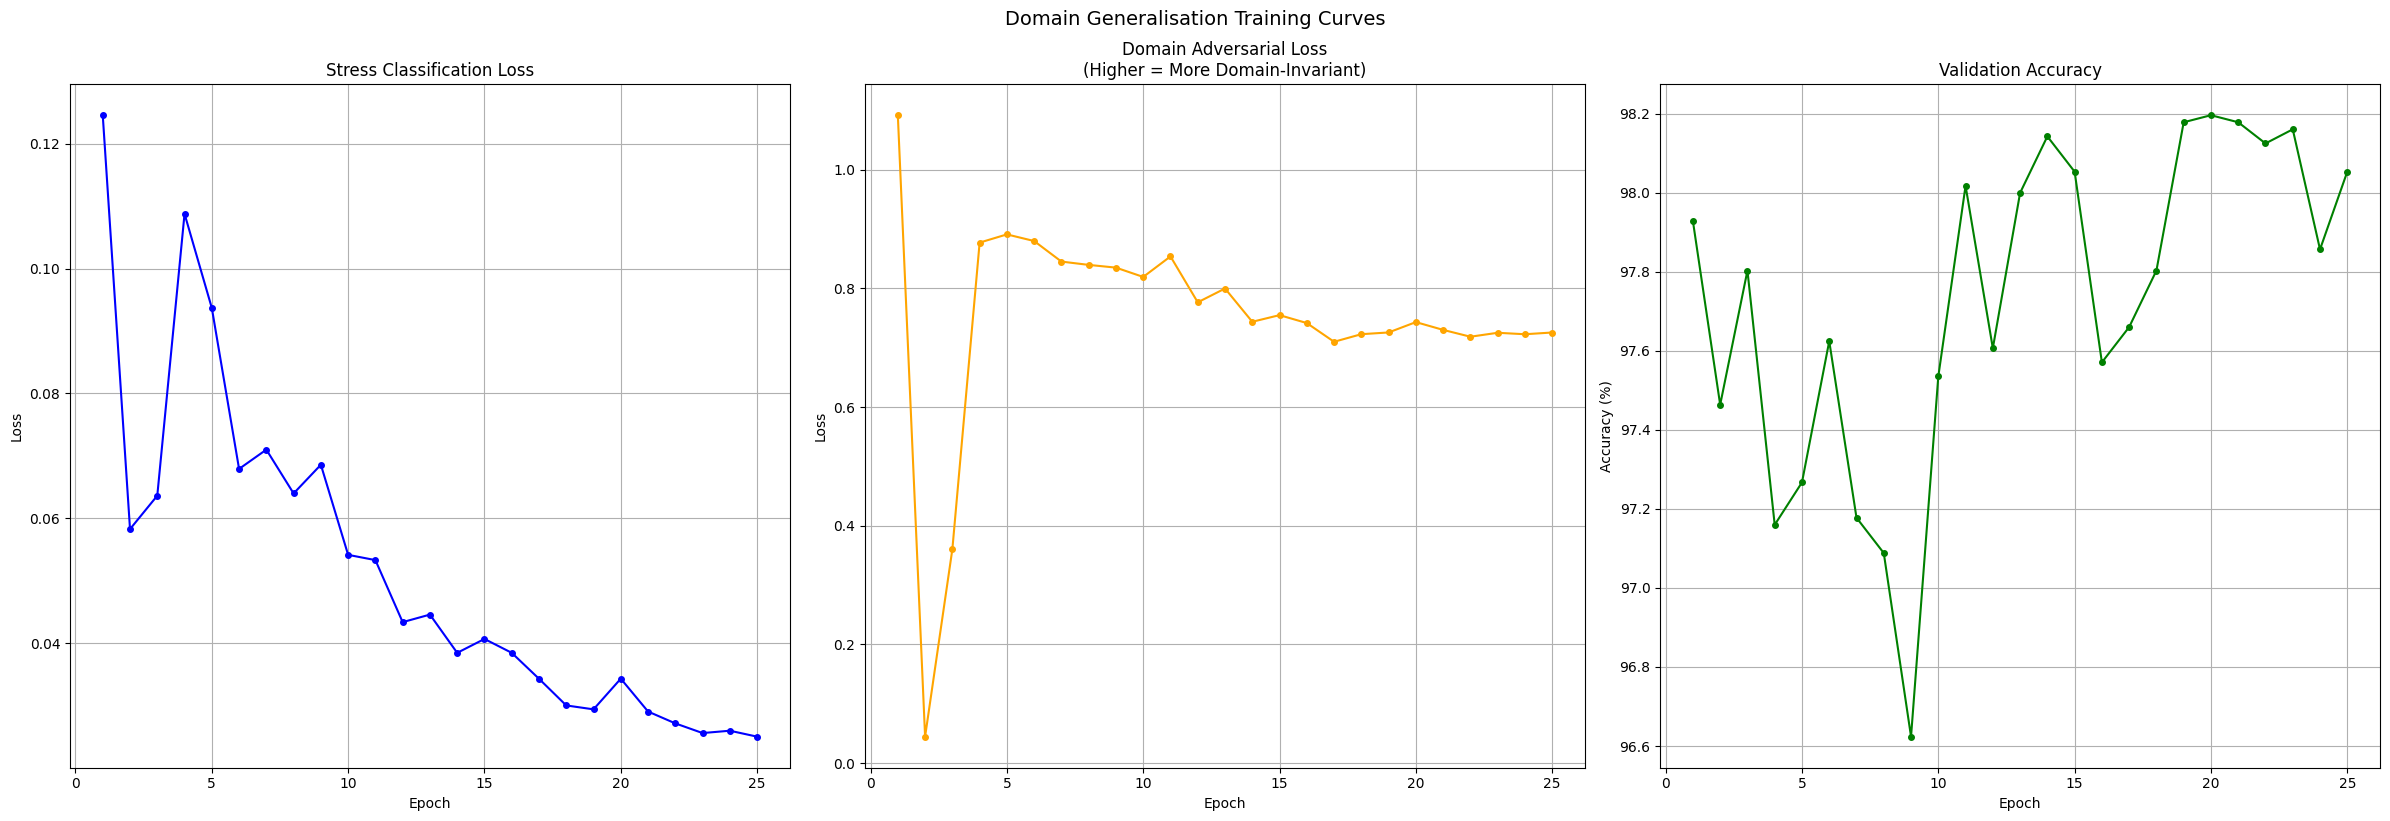

In [14]:
def plot_training_curves(stress_losses, domain_losses, val_accs):
    """
    Plots the training history so you can diagnose:
    - Is stress loss decreasing? (model is learning)
    - Is domain loss stable/high? (model is successfully domain-blind)
    - Is val accuracy rising and plateauing? (generalising, not overfitting)
    """
    epochs = range(1, len(stress_losses) + 1)
 
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
 
    # Plot 1: Stress Loss
    axes[0].plot(epochs, stress_losses, 'b-o', markersize=4)
    axes[0].set_title("Stress Classification Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
 
    # Plot 2: Domain Loss
    # A healthy domain loss stays relatively HIGH (model can't identify domains)
    # If it drops to near 0, the backbone is still domain-specific - try increasing lambda
    axes[1].plot(epochs, domain_losses, 'r-o', markersize=4, color='orange')
    axes[1].set_title("Domain Adversarial Loss\n(Higher = More Domain-Invariant)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
 
    # Plot 3: Validation Accuracy
    axes[2].plot(epochs, val_accs, 'g-o', markersize=4)
    axes[2].set_title("Validation Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy (%)")
    axes[2].grid(True)
 
    plt.tight_layout()
    plt.suptitle("Domain Generalisation Training Curves", y=1.02, fontsize=14)
    plt.show()
 
 
plot_training_curves(dg_stress_losses, dg_domain_losses, dg_val_accs)